# 05.03 — Final Model: Evaluation, SHAP & Predictions
**Goal:**
1. Load the best model from experiments
2. Full evaluation with all plots
3. SHAP explanations — why is each customer high risk?
4. Score ALL 2025 Won customers → produce final prediction CSV
5. The prediction CSV is what the customer success team uses

**The final output:** `reports/churn_predictions_2025.csv`
- Co_Ref
- churn_probability (0-1)
- risk_tier (Critical / High / Medium / Low)
- top 3 reasons per customer


In [3]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
emails= data['emails']
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print(f"  emails:        {emails.shape}")
print(f"  renewal_calls: {rc.shape}")

import json, shap
from xgboost import XGBClassifier
from src.features.builder import build_cohort_features, get_feature_columns
from src.models.train import find_optimal_threshold, assign_risk_tier, DEFAULT_PARAMS
from src.models.evaluate import evaluate_model, plot_feature_importance, threshold_analysis, plot_calibration


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        (123389, 28)
  renewal_calls: (186534, 41)


## Load Model and Feature Tables

In [4]:

train_df = pd.read_parquet(FEATURES / 'train_2024.parquet')
test_df  = pd.read_parquet(FEATURES / 'test_2025.parquet')

with open(FEATURES / 'final_feature_cols.json') as f:
    feature_cols = json.load(f)
with open(MODELS / 'best_params.json') as f:
    best_params = json.load(f)

best_params['scale_pos_weight'] = best_params.get('scale_pos_weight', 9.5)
best_params['random_state'] = 42
best_params['n_jobs'] = -1

test_decided = test_df[test_df['churn_label'].notna()].copy()
test_decided['churn_label'] = test_decided['churn_label'].astype(int)

X_train = train_df[feature_cols]
y_train = train_df['churn_label'].astype(int)
X_test  = test_decided[feature_cols]
y_test  = test_decided['churn_label']

print(f"Train: {X_train.shape}")
print(f"Test (decided): {X_test.shape}")
print(f"Features: {len(feature_cols)}")


Train: (30946, 51)
Test (decided): (32726, 51)
Features: 51


## Retrain on Full Training Set with Best Params

In [5]:

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
final_model.save_model(str(MODELS / 'churn_model_final.json'))
print("Final model saved.")


[0]	validation_0-aucpr:0.79811
[50]	validation_0-aucpr:0.79410
[100]	validation_0-aucpr:0.79307
[150]	validation_0-aucpr:0.79445
[200]	validation_0-aucpr:0.79996
[250]	validation_0-aucpr:0.80124
[300]	validation_0-aucpr:0.80409
[350]	validation_0-aucpr:0.80145
[400]	validation_0-aucpr:0.80025
[450]	validation_0-aucpr:0.79891
[500]	validation_0-aucpr:0.79719
[550]	validation_0-aucpr:0.79649
[599]	validation_0-aucpr:0.79559
Final model saved.


## Full Evaluation on Test Set

Model Evaluation — final
  Threshold used:    0.000
  PR-AUC:            0.7956
  ROC-AUC:           0.5108
  Precision:         0.7888
  Recall:            1.0000
  F1:                0.8819

  Total test customers:  32,726
  Actual churners:       25,814
  Customers flagged:     32,725
  Churners caught:       25,814 (100.0%)
  Churners missed:       0

              precision    recall  f1-score   support

    Retained       1.00      0.00      0.00      6912
     Churned       0.79      1.00      0.88     25814

    accuracy                           0.79     32726
   macro avg       0.89      0.50      0.44     32726
weighted avg       0.83      0.79      0.70     32726



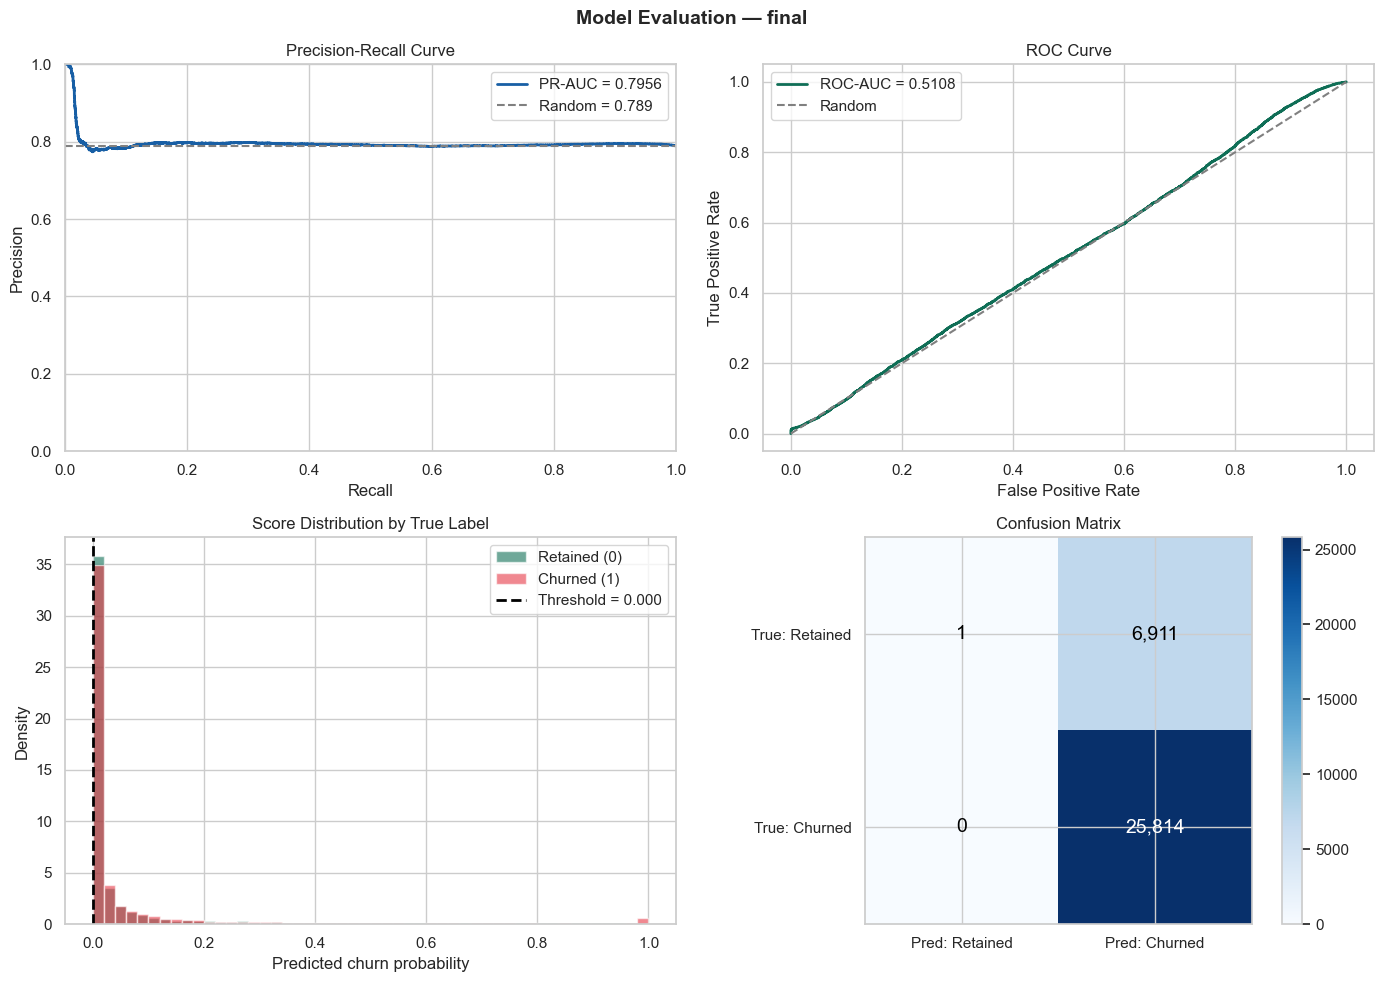

Plot saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\figures\final_evaluation.png

Optimal threshold: 0.000

Full threshold analysis:
 threshold  precision  recall     f1  flagged  caught
    0.0500     0.7970  0.2060 0.3270     6669    5313
    0.1000     0.7970  0.1460 0.2470     4739    3775
    0.1500     0.7900  0.1150 0.2000     3746    2961
    0.2000     0.7820  0.0930 0.1670     3080    2410
    0.2500     0.7840  0.0810 0.1470     2661    2086
    0.3000     0.7830  0.0700 0.1290     2315    1812
    0.3500     0.7800  0.0620 0.1140     2037    1588
    0.4000     0.7790  0.0550 0.1030     1834    1429
    0.4500     0.7810  0.0500 0.0940     1652    1291
    0.5000     0.7750  0.0450 0.0850     1491    1155


In [6]:

final_metrics = evaluate_model(final_model, X_test, y_test,
                                model_name='final', save_plots=True)

proba_test = final_model.predict_proba(X_test)[:,1]
optimal_threshold = find_optimal_threshold(y_test.values, proba_test,
                                            min_precision=0.25, min_recall=0.50)
print(f"\nOptimal threshold: {optimal_threshold:.3f}")
print("\nFull threshold analysis:")
_ = threshold_analysis(y_test.values, proba_test)


## Calibration

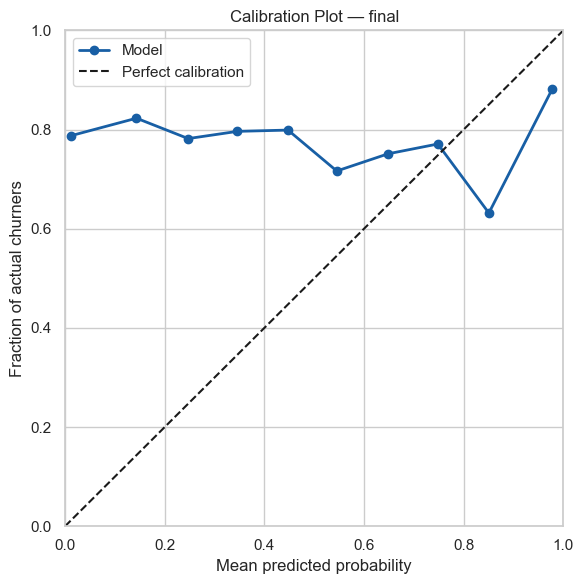

Saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\figures\final_calibration.png


In [7]:

plot_calibration(y_test.values, proba_test, model_name='final')


## Feature Importance — Final Model

Saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\figures\final_feature_importance.png


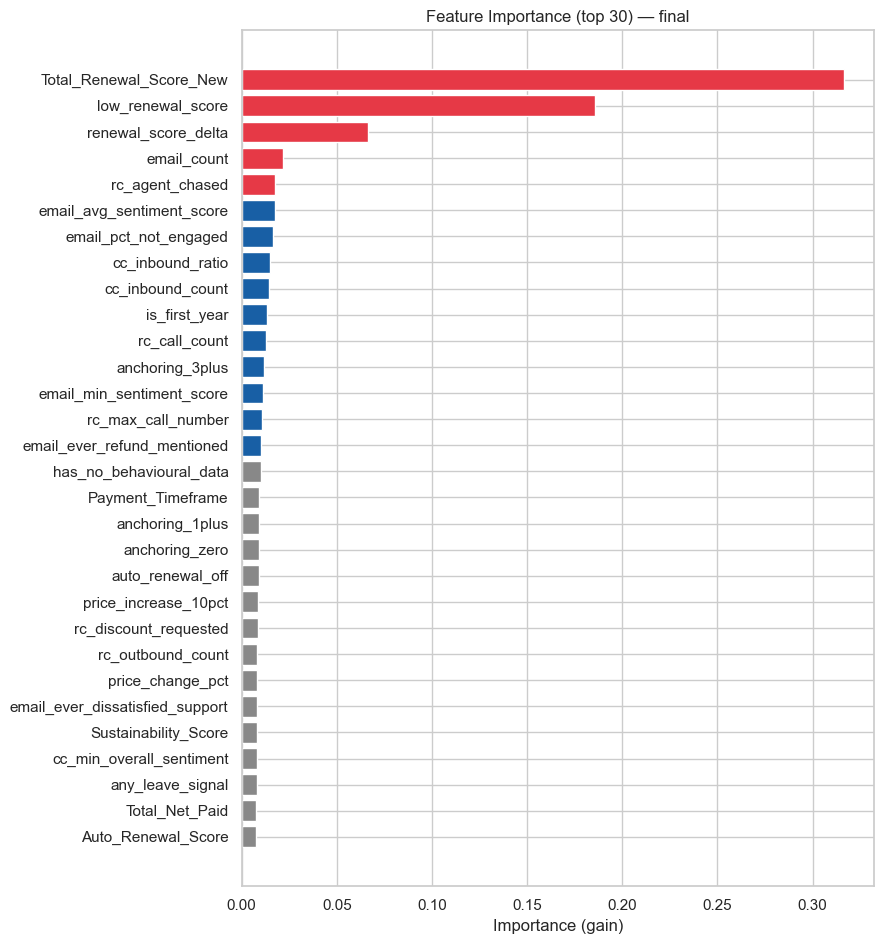

In [8]:

fi_df = plot_feature_importance(final_model, feature_cols, top_n=30, model_name='final')


## SHAP Explanations
**Why SHAP?**
Feature importance tells you what the model uses globally.
SHAP tells you WHY a specific customer was scored high — personalised explanations.
This is what the customer success team needs for their outreach conversations.


Computing SHAP values (this takes ~1-2 minutes)...
SHAP values shape: (30946, 51)


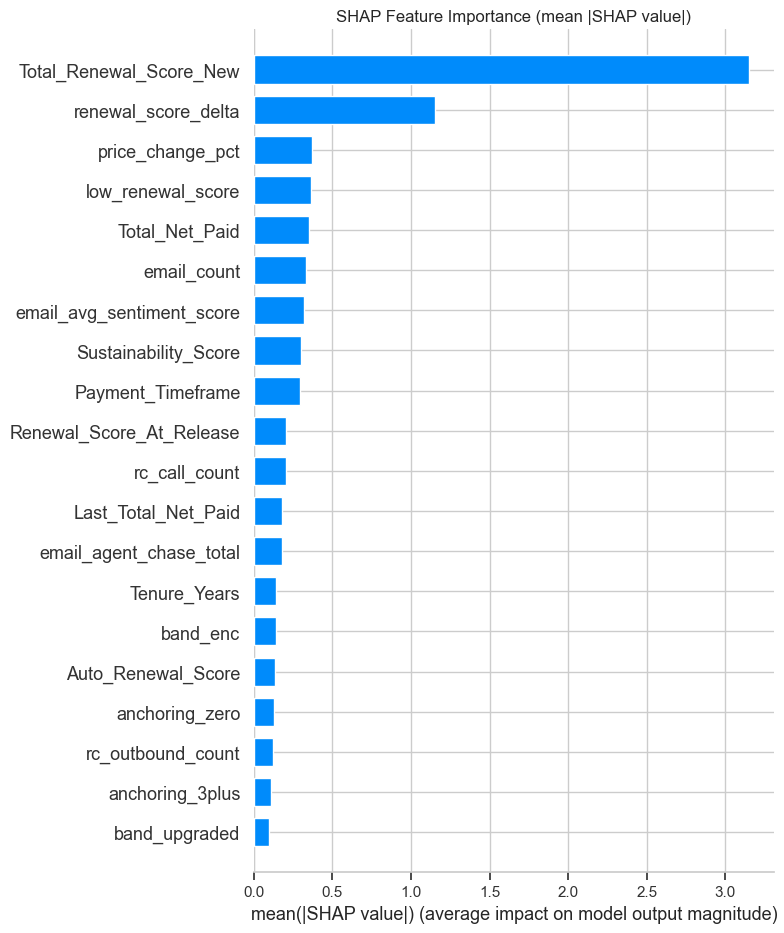

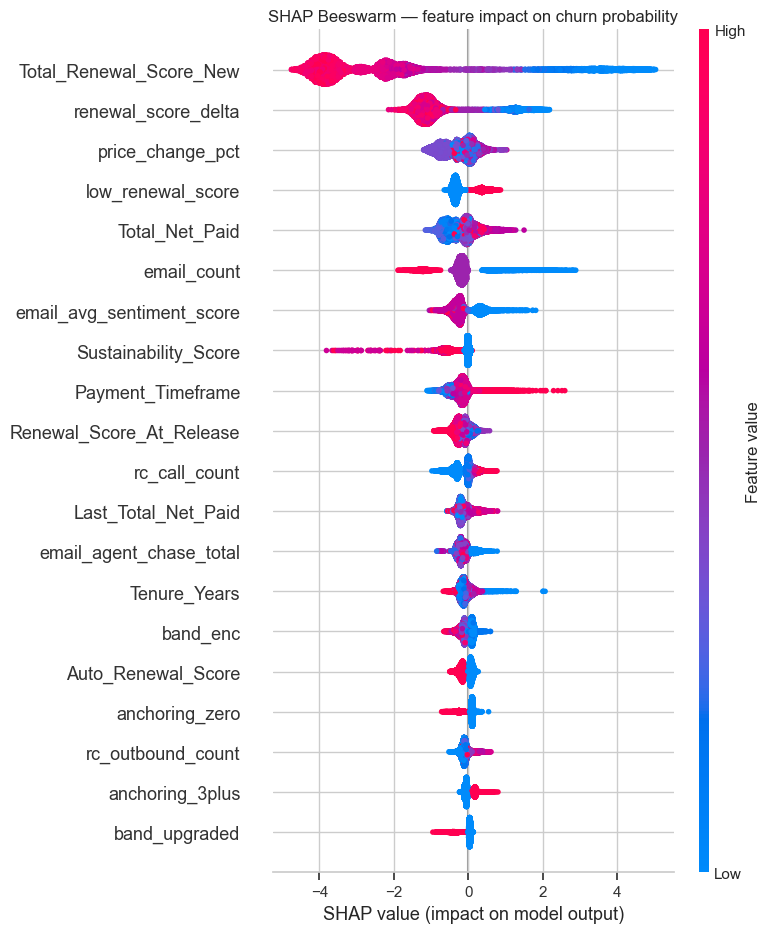

In [9]:

print("Computing SHAP values (this takes ~1-2 minutes)...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train)

print(f"SHAP values shape: {shap_values.shape}")

# ── Global SHAP summary plot ──────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig(REPORTS / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Beeswarm plot (shows direction too) ──────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train, feature_names=feature_cols,
                  plot_type='dot', show=False, max_display=20)
plt.title('SHAP Beeswarm — feature impact on churn probability')
plt.tight_layout()
plt.savefig(REPORTS / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


## SHAP Individual Customer Explanation Examples


Rank 1 highest risk — Co_Ref: NK1187  Probability: 1.000
Actual label: 1


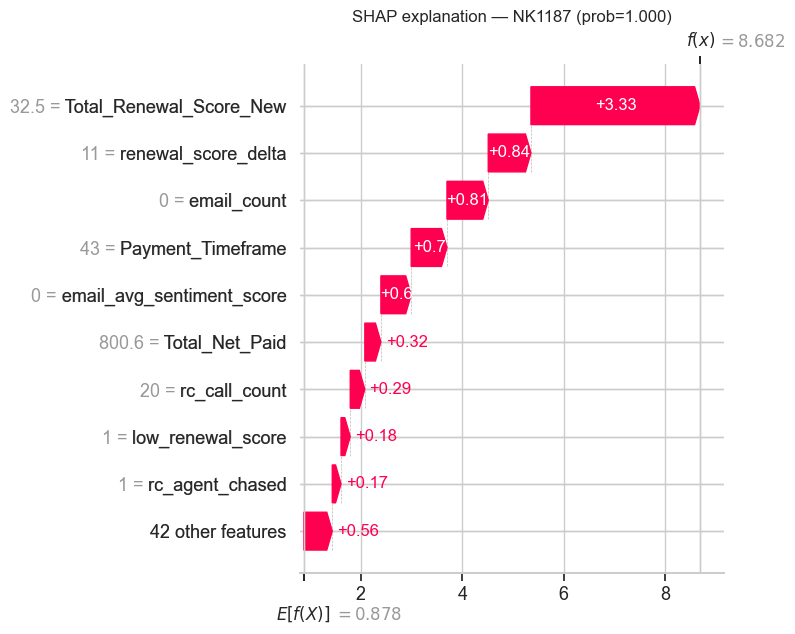


Rank 2 highest risk — Co_Ref: RO4659  Probability: 1.000
Actual label: 1


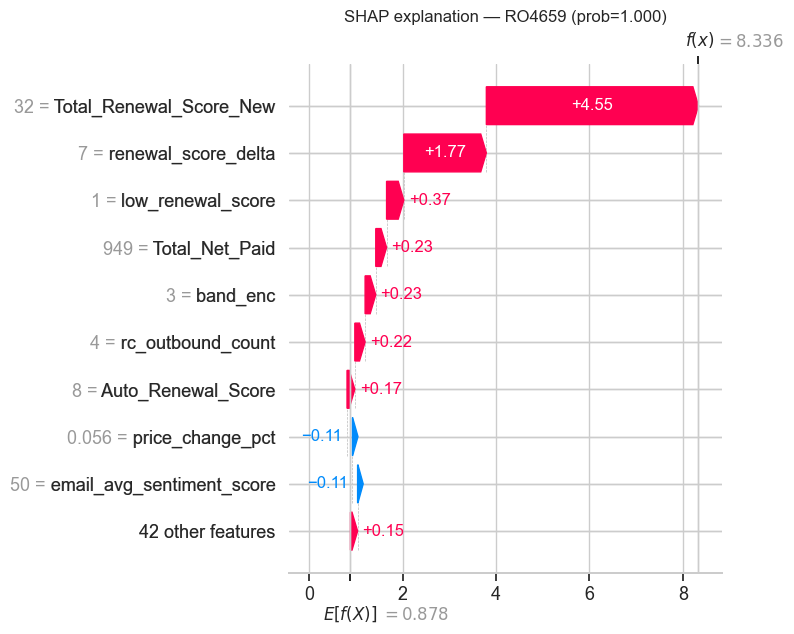


Rank 3 highest risk — Co_Ref: LA3122  Probability: 1.000
Actual label: 1


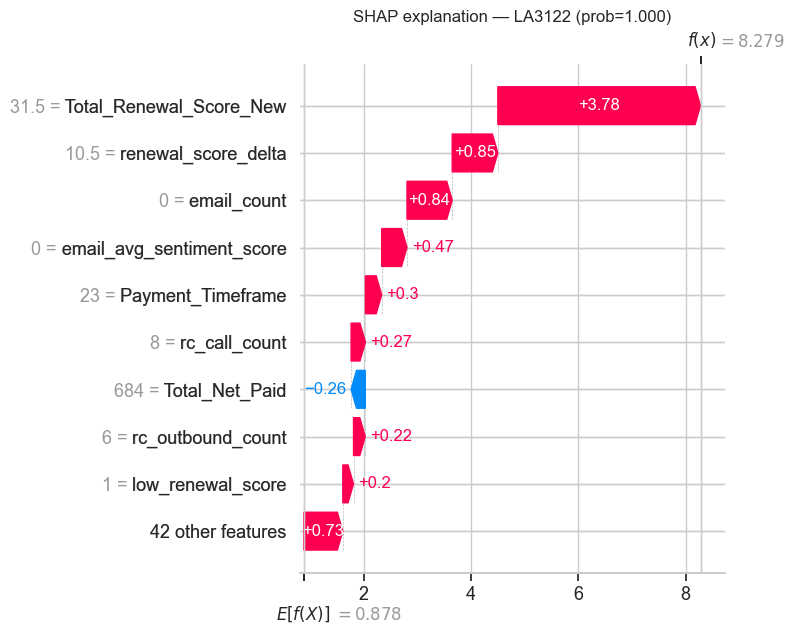

In [10]:

# Show explanations for top 3 high-risk customers from test set
proba_train = final_model.predict_proba(X_train)[:,1]
top3_idx = np.argsort(proba_train)[-3:][::-1]

for rank, idx in enumerate(top3_idx):
    co_ref = train_df.iloc[idx]['Co_Ref']
    prob   = proba_train[idx]
    print(f"\n{'='*50}")
    print(f"Rank {rank+1} highest risk — Co_Ref: {co_ref}  Probability: {prob:.3f}")
    print(f"Actual label: {y_train.iloc[idx]}")

    plt.figure(figsize=(12, 3))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_train.iloc[idx],
            feature_names=feature_cols
        ),
        show=False, max_display=10
    )
    plt.title(f'SHAP explanation — {co_ref} (prob={prob:.3f})')
    plt.tight_layout()
    plt.savefig(REPORTS / f'shap_customer_{rank+1}.png', dpi=150, bbox_inches='tight')
    plt.show()


## Score ALL 2025 Won Customers — Final Predictions
This is the real business output. Every customer who renewed in 2025 gets a churn probability score and a risk tier.


In [11]:

# Build prediction features (same pipeline, no labels)
print("Building 2025 prediction features...")
pred_df = build_cohort_features(bills, emails, cc, rc, renewal_year=2025, include_labels=False)

# ensure same feature columns
for col in feature_cols:
    if col not in pred_df.columns:
        pred_df[col] = 0

X_pred = pred_df[feature_cols].fillna(0)

# score
pred_proba = final_model.predict_proba(X_pred)[:,1]
pred_df['churn_probability'] = pred_proba
pred_df['risk_tier'] = assign_risk_tier(pred_proba)
pred_df['churn_flag'] = (pred_proba >= optimal_threshold).astype(int)

print(f"\nScored {len(pred_df):,} customers")
print("\nRisk tier distribution:")
print(pred_df['risk_tier'].value_counts())
print(f"\nCustomers flagged for outreach: {pred_df['churn_flag'].sum():,}")


Building 2025 prediction features...
[2025] Base: 32,726 customers
[2025] Coverage — emails:31,538 cc:12,069 rc:23,722
[2025] Final: (32726, 99) ✓

Scored 32,726 customers

Risk tier distribution:
risk_tier
Low         13090
Medium       9818
High         6545
Critical     3273
Name: count, dtype: int64

Customers flagged for outreach: 32,725


## Add Top 3 SHAP Reasons per Customer

In [12]:

print("Computing SHAP for prediction set...")
shap_pred = explainer.shap_values(X_pred)

def top_reasons(shap_row, feature_names, n=3):
    """Return top N features by absolute SHAP value."""
    idx = np.argsort(np.abs(shap_row))[-n:][::-1]
    reasons = []
    for i in idx:
        direction = 'increases' if shap_row[i] > 0 else 'decreases'
        reasons.append(f"{feature_names[i]} ({direction} risk)")
    return ' | '.join(reasons)

pred_df['top_reasons'] = [
    top_reasons(shap_pred[i], feature_cols)
    for i in range(len(pred_df))
]

print("Sample predictions for Critical Risk customers:")
critical = pred_df[pred_df['risk_tier']=='Critical'][
    ['Co_Ref','churn_probability','risk_tier','top_reasons']
].head(10)
print(critical.to_string(index=False))


Computing SHAP for prediction set...
Sample predictions for Critical Risk customers:
Co_Ref  churn_probability risk_tier                                                                                                                  top_reasons
DV8120             0.9991  Critical               Total_Renewal_Score_New (increases risk) | renewal_score_delta (increases risk) | email_count (increases risk)
EC7710             0.3183  Critical            Total_Renewal_Score_New (decreases risk) | renewal_score_delta (decreases risk) | Total_Net_Paid (increases risk)
OV0744             0.3485  Critical                  low_renewal_score (increases risk) | renewal_score_delta (decreases risk) | anchoring_zero (decreases risk)
KZ2465             0.2775  Critical         Total_Renewal_Score_New (decreases risk) | renewal_score_delta (decreases risk) | low_renewal_score (increases risk)
HZ9981             0.4189  Critical renewal_score_delta (decreases risk) | Total_Renewal_Score_New (increases 

## Save Final Predictions CSV

In [13]:

output_cols = ['Co_Ref','churn_probability','risk_tier','churn_flag','top_reasons',
               'Band','Tenure_Years','Current_Anchorings','auto_renewal_off','payment_unknown']
output_cols = [c for c in output_cols if c in pred_df.columns]

predictions = pred_df[output_cols].sort_values('churn_probability', ascending=False)
predictions['churn_probability'] = predictions['churn_probability'].round(4)

output_path = PROJECT_ROOT / 'reports' / 'churn_predictions_2025.csv'
predictions.to_csv(output_path, index=False)
print(f"Saved → {output_path}")
print(f"Total customers scored: {len(predictions):,}")
print()
print("=== FINAL SUMMARY ===")
print(f"Critical risk:  {(predictions['risk_tier']=='Critical').sum():,} customers")
print(f"High risk:      {(predictions['risk_tier']=='High').sum():,} customers")
print(f"Medium risk:    {(predictions['risk_tier']=='Medium').sum():,} customers")
print(f"Low risk:       {(predictions['risk_tier']=='Low').sum():,} customers")
print(f"\nFlagged for outreach: {predictions['churn_flag'].sum():,}")
print(f"\nModel PR-AUC: {final_metrics['pr_auc']:.4f}")
print(f"Model ROC-AUC: {final_metrics['roc_auc']:.4f}")
print(f"Precision @ threshold: {final_metrics['precision']:.4f}")
print(f"Recall    @ threshold: {final_metrics['recall']:.4f}")


Saved → c:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\churn_predictions_2025.csv
Total customers scored: 32,726

=== FINAL SUMMARY ===
Critical risk:  3,273 customers
High risk:      6,545 customers
Medium risk:    9,818 customers
Low risk:       13,090 customers

Flagged for outreach: 32,725

Model PR-AUC: 0.7956
Model ROC-AUC: 0.5108
Precision @ threshold: 0.7888
Recall    @ threshold: 1.0000
